SPDX-FileCopyrightText: Copyright (c) 2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.

SPDX-License-Identifier: Apache-2.0

# Lab 2: Synthetic Data Generation: From Seed Image to Augmented Video

This notebook demonstrates how generative models can scale a single seed image into a large, diverse set of training videos — without additional real-world data collection.

**Why synthetic data?** Collecting and labeling real-world video for AI training is expensive and, for many scenarios, practically impossible. Rare or dangerous events — a vehicle stalled at an intersection, a pedestrian crossing in dense fog, a near-collision in heavy rain — happen infrequently in the real world and are difficult to capture at scale. Covering the full range of environmental conditions (lighting, weather, time of day) and edge cases required for a robust model would demand years of footage and enormous labeling effort. Synthetic Data Generation (SDG) solves this: it lets you create rare events on demand, augment existing footage with new conditions, and systematically expand your dataset across scenarios that would otherwise be missing from your training distribution.


| Stage | What it is | Main variation introduced | Intended invariants |
|---|---|---|---|
| **I2I** — Image-to-Image | Modifies an existing image based on a text instruction; structure and content are largely preserved | Scene appearance (lighting, weather, style) | Composition and subject identity |
| **I2V** — Image-to-Video | Generates a video clip from a still image, anchoring the first frame | Temporal behavior (motion, events) | Starting image and scene context |
| **V2V** — Video-to-Video | Re-renders a video's visual appearance while preserving coarse structure and motion | Video appearance (materials, environment) | Coarse structure and motion |

Note that the invariants above reflect *intended conditioning behavior* — generated outputs can drift, hallucinate, or exhibit temporal artifacts. Always review outputs before using them downstream.

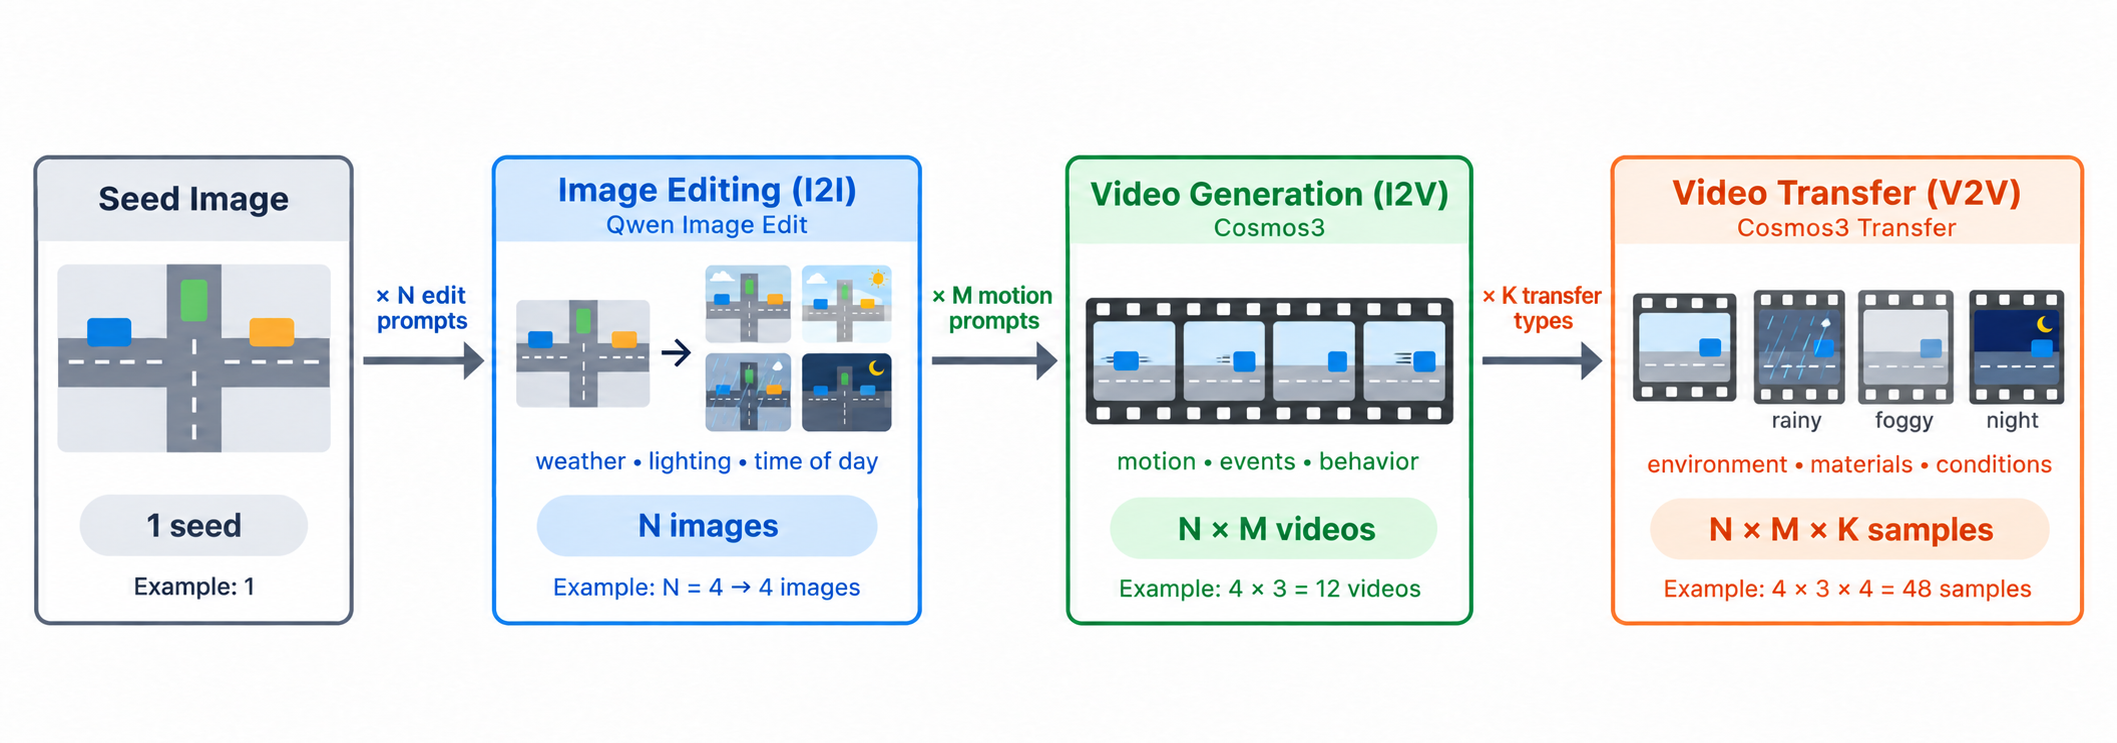

**Running example:** This notebook uses a traffic intersection camera frame as its seed image to make the stages concrete. The same pipeline applies to any domain — robotics, warehouses, retail, smart spaces — by swapping the seed image and prompts.

**How to run this notebook:** everything it needs — Python packages, model weights, the Cosmos framework — is already installed in the lab image, so nothing is downloaded and no token or API key is required. Do not use "Run All": run the cells one at a time, top to bottom, and wait for each GPU step (the Qwen load, the Qwen edit, the I2V generation, and the transfer) to finish before continuing. Qwen runs on GPU 0 inside this kernel and Cosmos runs on GPU 1 as a subprocess; the whole notebook fits a 30-minute slot.

### Learning Objectives

By the end of this notebook you will be able to:
- Explain why synthetic data generation is necessary and identify the scenarios where real-world data collection falls short
- Describe what each pipeline stage contributes and what it preserves, so you can diagnose and adjust outputs that don't meet expectations
- Craft prompts and tune parameters to generate targeted variation — specific conditions, behaviors, or appearance changes — for a given training need
- Apply the compound scaling model (N×M×K) to plan a synthetic dataset from a single seed image

### Table of Contents

**[Part 0: Seed Image](#Part-0:-Seed-Image)**  
**[Part 1: Image Augmentation with Qwen](#Part-1:-Image-Augmentation-with-Qwen)**  
&nbsp;&nbsp;&nbsp;&nbsp;[1.1 Load Pipeline](#1.1-Load-Pipeline)  
&nbsp;&nbsp;&nbsp;&nbsp;[1.2 Craft an Edit Prompt](#1.2-Craft-an-Edit-Prompt)  
&nbsp;&nbsp;&nbsp;&nbsp;[1.3 Run Augmentation](#1.3-Run-Augmentation)  
**[Part 2: Image-to-Video Generation with Cosmos](#Part-2:-Image-to-Video-Generation-with-Cosmos)**  
&nbsp;&nbsp;&nbsp;&nbsp;[2.1 Environment Setup](#2.1-Environment-Setup)  
&nbsp;&nbsp;&nbsp;&nbsp;[2.2 Structured Prompts](#2.2-Structured-Prompts)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[2.2.1 Generate a Prompt with AI (Optional)](#2.2.1-Generate-a-Prompt-with-AI-(Optional))  
&nbsp;&nbsp;&nbsp;&nbsp;[2.3 Run Image-to-Video Inference](#2.3-Run-Image-to-Video-Inference)  
**[Part 3: Video Augmentation with Cosmos](#Part-3:-Video-Augmentation-with-Cosmos)**  
&nbsp;&nbsp;&nbsp;&nbsp;[3.1 Transfer Controls](#3.1-Transfer-Controls)  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;[3.1.1 Generate a Transfer Prompt with AI (Optional)](#3.1.1-Generate-a-Transfer-Prompt-with-AI-(Optional))  
&nbsp;&nbsp;&nbsp;&nbsp;[3.2 Run Edge Transfer](#3.2-Run-Edge-Transfer)  
**[Part 4: Tear Down](#Part-4:-Tear-Down)**  
**[Review](#Review)**

## Setup

All Python dependencies are already installed in the lab image, so there is nothing to install here. Run the cell below once per kernel session — it defines the paths, GPU indices and model locations that every later cell reads.

In [ ]:
# ── Lab 2 environment block: the single source of truth for paths, models, GPUs and endpoints ──
import os, socket
from pathlib import Path


def _env_path(name, default):
    return Path(os.environ.get(name, str(default))).expanduser()


def _free_local_port():
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(("127.0.0.1", 0))
        return str(s.getsockname()[1])


# ── Notebook layout ───────────────────────────────────────────────────────────
LAB_ROOT = _env_path("LAB_ROOT", "/dli/task/lab-2-sdg")
if not LAB_ROOT.exists():
    LAB_ROOT = Path.cwd().resolve()
ASSETS  = LAB_ROOT / "assets"                   # shipped, read-only course assets
INPUTS  = ASSETS / "inputs"                     # seed image
PROMPTS = ASSETS / "prompts"                    # structured prompt files (presets)
OUTPUTS = _env_path("LAB_OUTPUTS", ASSETS / "outputs")             # learner-generated runs, one timestamped folder each
CONFIGS = ASSETS / "configs"
for _d in (OUTPUTS, CONFIGS, OUTPUTS / "prompts"):
    _d.mkdir(parents=True, exist_ok=True)

SEED_IMAGE_NAME = os.environ.get("SDG_SEED_IMAGE", "site03_median.jpg")
seed_image_path = INPUTS / SEED_IMAGE_NAME

# ── Hugging Face: fully offline against the pre-seeded cache (must run BEFORE importing diffusers/transformers) ──
HF_HOME = _env_path("HF_HOME", "/dli/task/data/hf_home")           # staged by the course loader into the data volume
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_HUB_OFFLINE"] = "1"              # cached files only - no HTTP to huggingface.co
os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"] = "1"
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ.pop("HF_TOKEN", None)

# Qwen Image Edit: the pinned snapshot inside HF_HOME.
QWEN_REVISION = os.environ.get("QWEN_REVISION", "ac7f9318f633fc4b5778c59367c8128225f1e3de")
_qwen_snapshot = HF_HOME / "hub" / "models--Qwen--Qwen-Image-Edit" / "snapshots" / QWEN_REVISION
QWEN_MODEL_PATH = os.environ.get("QWEN_MODEL_PATH", str(_qwen_snapshot))

# ── Cosmos 3 framework (pre-installed, own venv, runs as a subprocess on COSMOS_GPU) ──
COSMOS3_REPO = _env_path("COSMOS3_REPO", "/opt/cosmos3-framework")
COSMOS3_VENV_PYTHON = COSMOS3_REPO / ".venv" / "bin" / "python"
COSMOS_ROOT = _env_path("COSMOS_ROOT", "/dli/task/cosmos")
COSMOS3_CHECKPOINT = os.environ.get("COSMOS3_CHECKPOINT_PATH", "Cosmos3-Nano")
COSMOS3_NANO_REVISION = os.environ.get("COSMOS3_NANO_REVISION", "7a312c868bcce8e40b3eb40861300a9d0ba3fde1")
COSMOS_GUARDRAIL_REVISION = os.environ.get("COSMOS_GUARDRAIL_REVISION", "d6d4bfa899a71454a700907664f3e88f503950cf")
WAN_VAE_REVISION = os.environ.get("WAN_VAE_REVISION", "921dbaf3f1674a56f47e83fb80a34bac8a8f203e")

_hub_dir = HF_HOME / "hub"
if _hub_dir.is_dir():
    for _repo_dir in sorted(_hub_dir.glob("models--*")):
        _snaps = [p for p in (_repo_dir / "snapshots").glob("*") if p.is_dir()] if (_repo_dir / "snapshots").is_dir() else []
        _ref = _repo_dir / "refs" / "main"
        if len(_snaps) == 1 and not _ref.exists():
            try:
                _ref.parent.mkdir(parents=True, exist_ok=True)
                _ref.write_text(_snaps[0].name)
                print(f"Restored {_ref} -> {_snaps[0].name[:12]}")
            except OSError as _e:
                print(f"WARNING could not write {_ref} ({_e}) - lookups by branch name will fail offline; ask a TA.")

# ── GPU plan on the 2x H100 learner VM ──
QWEN_GPU   = os.environ.get("QWEN_GPU", "0")     # Qwen Image Edit lives in this kernel on cuda:<QWEN_GPU>
COSMOS_GPU = os.environ.get("COSMOS_GPU", "1")   # Cosmos 3 runs in a subprocess; this becomes ITS CUDA_VISIBLE_DEVICES
DEVICE = "cuda:0"

DOCKER_HOST = os.environ.get("DOCKER_HOST", "tcp://dind:2375")
LAB1_NIM_CONTAINER = os.environ.get("LAB1_NIM_CONTAINER", "cosmos3-reasoner")

# ── Nemotron NIM (2.2.1 / 3.1.1 prompt generation, GPU 0, port 30083) ─────────
NEMOTRON_NIM_IMAGE   = os.environ.get("NEMOTRON_NIM_IMAGE",   "nvcr.io/nim/nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:1.7.0-variant")   # pinned: the tag the launch seed pulls
NEMOTRON_NIM_CONTAINER = os.environ.get("NEMOTRON_NIM_CONTAINER", "nemotron-nim")
NEMOTRON_NIM_CACHE   = _env_path("NEMOTRON_NIM_CACHE", "/dli/task/data/nemotron-nim-cache")   # visible here AND in dind at the same path
NEMOTRON_NIM_CACHE_MARKER = "zz_cache_complete"
NEMOTRON_NIM_PORT    = int(os.environ.get("NEMOTRON_NIM_PORT", "30083"))
NEMOTRON_MODEL_ID    = "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning"
_nim_host = DOCKER_HOST.replace("tcp://", "").split(":")[0] if DOCKER_HOST.startswith("tcp://") else "127.0.0.1"
NEMOTRON_NIM_BASE_URL = os.environ.get("NEMOTRON_NIM_BASE_URL", f"http://{_nim_host}:{NEMOTRON_NIM_PORT}")   # http://dind:30083 in the lab

# ── Exports read by the %%bash inference cells and the Cosmos subprocess ──
os.environ["COSMOS3_REPO"] = str(COSMOS3_REPO)
os.environ["COSMOS3_CHECKPOINT_PATH"] = COSMOS3_CHECKPOINT
os.environ.setdefault("COSMOS3_NUM_GPUS", "1")
os.environ.setdefault("COSMOS3_MASTER_ADDR", "127.0.0.1")
os.environ.setdefault("COSMOS3_MASTER_PORT", _free_local_port())
os.environ["COSMOS_CUDA_VISIBLE_DEVICES"] = COSMOS_GPU
os.environ.setdefault("UV_OFFLINE", "1")
_hf_cli_env = COSMOS3_REPO / ".hf-cli-venv"
if _hf_cli_env.exists():
    os.environ.setdefault("IMAGINAIRE_HF_CLI_ENVIRONMENT", str(_hf_cli_env))

# ── Summary ──
_checks = {
    "seed image": seed_image_path,
    "prompt presets": PROMPTS / "i2v_normal_traffic.json",
    "HF cache (HF_HOME)": HF_HOME,
    "Qwen Image Edit snapshot": _qwen_snapshot,
    "Cosmos3-Nano snapshot": HF_HOME / "hub" / "models--nvidia--Cosmos3-Nano" / "snapshots" / COSMOS3_NANO_REVISION,
    "Cosmos-Guardrail1 snapshot": HF_HOME / "hub" / "models--nvidia--Cosmos-Guardrail1" / "snapshots" / COSMOS_GUARDRAIL_REVISION,
    "Qwen3Guard text guardrail snapshot": HF_HOME / "hub" / "models--Qwen--Qwen3Guard-Gen-0.6B" / "snapshots",
    "Wan2.2 video VAE (Wan2.2_VAE.pth)": HF_HOME / "hub" / "models--Wan-AI--Wan2.2-TI2V-5B" / "snapshots" / WAN_VAE_REVISION / "Wan2.2_VAE.pth",
    "Cosmos framework venv": COSMOS3_VENV_PYTHON,
    "Cosmos checkpoint CLI env (lab image)": _hf_cli_env,
    "Nemotron NIM cache": NEMOTRON_NIM_CACHE,
}
for _k, _p in _checks.items():
    print(f"{'OK     ' if _p.exists() else 'MISSING'} {_k}: {_p}")
print(f"\nGPU map: Qwen -> GPU {QWEN_GPU} | Cosmos -> GPU {COSMOS_GPU} | checkpoint {COSMOS3_CHECKPOINT}")
print(f"Outputs: {OUTPUTS}")
print(f"LLM prompt drafting (optional): Nemotron NIM at {NEMOTRON_NIM_BASE_URL}")
if any(not _p.exists() for _p in _checks.values()):
    print("\nSomething is MISSING: the lab data loader may still be running. Wait a few minutes and re-run this cell. Do not download anything.")

In [ ]:
# ── Preflight gate: do not continue if anything above is MISSING ──
_missing = [k for k, p in _checks.items() if not p.exists()]
if _missing:
    raise RuntimeError(
        "The following resources are not yet available:\n"
        + "".join(f"  • {k}\n" for k in _missing)
        + "\nThe course data loader may still be running. "
        "Wait a few minutes, re-run the cell above, then re-run this cell. "
        "Do not skip ahead."
    )
print("All resources available — ready to proceed.")

### GPU preflight

The cell below stops the Lab 1 model server if it is still running on GPU 0, removes a Nemotron NIM left over from an earlier Lab 2 run (both are no-ops otherwise), and reports the free memory on each GPU.

In [ ]:
# Preflight: stop leftover Lab 1 / Lab 2 model servers (idempotent) and check free GPU memory.
import json, shutil, subprocess, time, urllib.request, urllib.error
import torch

_api = "http://" + DOCKER_HOST.replace("tcp://", "")


def _docker(method, path, timeout=60):
    req = urllib.request.Request(f"{_api}{path}", method=method)
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.status


try:
    _docker("GET", f"/containers/{LAB1_NIM_CONTAINER}/json", timeout=10)
    print(f"Found leftover container '{LAB1_NIM_CONTAINER}' from Lab 1 - stopping and removing it ...")
    try:
        _docker("POST", f"/containers/{LAB1_NIM_CONTAINER}/stop?t=30", timeout=120)
    except urllib.error.HTTPError as e:
        if e.code not in (304,):              # 304 = already stopped
            raise
    _docker("DELETE", f"/containers/{LAB1_NIM_CONTAINER}?force=1", timeout=60)
    print("Removed. Waiting 15 s for the GPU memory to be released ...")
    time.sleep(15)
except urllib.error.HTTPError as e:
    if e.code == 404:
        print(f"No '{LAB1_NIM_CONTAINER}' container running - Lab 1 was already torn down.")
    else:
        print(f"Docker API returned {e.code} - could not check '{LAB1_NIM_CONTAINER}' (continuing).")
except Exception as e:
    if shutil.which("docker"):
        r = subprocess.run(["docker", "-H", DOCKER_HOST, "rm", "-f", LAB1_NIM_CONTAINER], capture_output=True, text=True)
        print((r.stdout or r.stderr).strip() or f"docker rm -f {LAB1_NIM_CONTAINER}: done")
    else:
        print(f"Docker daemon at {DOCKER_HOST} not reachable ({type(e).__name__}) - skipping the Lab 1 container check.")

# Also remove a Nemotron NIM left over from an earlier Lab 2 run (2.2.1 starts it on GPU 0; Part 4 stops it).
_r = subprocess.run(["docker", "-H", DOCKER_HOST, "rm", "-f", NEMOTRON_NIM_CONTAINER], capture_output=True, text=True)
if _r.returncode == 0 and _r.stdout.strip():
    print(f"Removed leftover '{NEMOTRON_NIM_CONTAINER}' from an earlier Lab 2 run. Waiting 15 s for the GPU memory to be released ...")
    time.sleep(15)

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available in this kernel - check the GPU allocation with an instructor.")
_free_gib = {}
if shutil.which("nvidia-smi"):
    _q = subprocess.run(["nvidia-smi", "--query-gpu=index,memory.used,memory.total", "--format=csv,noheader,nounits"],
                        capture_output=True, text=True)
    for _ln in _q.stdout.strip().splitlines():
        _idx, _used, _total = (int(x) for x in _ln.split(","))
        _free_gib[_idx] = (_total - _used) / 1024
        print(f"GPU {_idx}: {(_total - _used) / 1024:.0f} GiB free of {_total / 1024:.0f} GiB")
else:
    for _i in range(torch.cuda.device_count()):
        _f, _t = torch.cuda.mem_get_info(_i)
        _free_gib[_i] = _f / 1024**3
        print(f"GPU {_i} (kernel view): {_f / 1024**3:.0f} GiB free of {_t / 1024**3:.0f} GiB")

_need = {int(QWEN_GPU): 60, int(COSMOS_GPU): 40}   # GiB: Qwen Image Edit bf16 ~57 GiB; Cosmos 3 Nano + guardrail
for _g, _min in _need.items():
    if _g in _free_gib and _free_gib[_g] < _min:
        print(f"WARNING: GPU {_g} has only {_free_gib[_g]:.0f} GiB free (< {_min} GiB needed). "
              "If Lab 1's model server or the Lab 2 Nemotron NIM is still running, re-run this cell after it stops; otherwise ask a TA.")
print(f"Plan: Qwen Image Edit -> GPU {QWEN_GPU} (this kernel sees it as cuda:0) | Cosmos 3 Nano -> GPU {COSMOS_GPU} (subprocess)")


---
## Part 0: Seed Image

*Estimated time: 1 minute.*

The seed image is the anchor for your entire SDG pipeline. It defines the scene, camera viewpoint, and visual context that all downstream stages inherit.

Place your own image in `assets/inputs/` and update `SEED_IMAGE_NAME` in the cell below. The default used here is a frame captured from a live overhead intersection camera.

**What makes a good seed image:**
- Clear, well-lit subject with a defined viewpoint
- Representative of your target deployment conditions
- High enough resolution for generation quality (480p or higher is ideal)
- Can be real (captured) or synthetic (rendered) — both work

Working directory paths are configured in the environment cell above.

In [ ]:
# --- Change the seed image here (optional) ---
# To start from a different image, copy it into assets/inputs/ and update the filename below.
SEED_IMAGE_NAME = "site03_median.jpg"   # filename inside assets/inputs/
seed_image_path = INPUTS / SEED_IMAGE_NAME
# -----------------------------------------------
print(f"Seed image: {seed_image_path}")

In [ ]:
from PIL import Image
from IPython.display import display

if not seed_image_path.exists():
    raise FileNotFoundError(
        f"Seed image not found: {seed_image_path}\n"
        f"The course assets have not landed or LAB_ROOT is wrong (currently {LAB_ROOT}).\n"
        f"To use your own image, copy it into {INPUTS} and set SDG_SEED_IMAGE=<filename> before running the environment cell. "
        "If the default image is missing in the lab, ask an instructor."
    )
seed_image = Image.open(seed_image_path).convert("RGB")
print(f"Loaded: {seed_image_path} | size: {seed_image.size}")
display(seed_image)

---
## Part 1: Image Augmentation with Qwen

*Estimated time: 6 minutes (GPU 0).*

Qwen Image Edit is an instruction-following image-to-image (I2I) model. Given an input image and a natural language instruction, it modifies the image according to the instruction while leaving unspecified attributes largely unchanged. In practice, outputs can still shift in unintended ways — particularly with strong edits — so reviewing the result is important.

In an SDG context, I2I augmentation is used to:
- Vary environmental conditions (lighting, weather, time of day)
- Change material or surface properties
- Add or remove scene elements
- Simulate sensor or camera variations

The model operates on the full image without requiring a mask — the instruction determines what changes.

### 1.1 Load Pipeline

This cell loads the Qwen model weights into GPU-0 memory. This takes 1-2min and only needs to run once per session — all subsequent edits reuse the loaded model.

In [ ]:
# 1.1 Load Qwen Image Edit from the local cache (nothing is downloaded in this lab)
import time
import torch
from diffusers import QwenImageEditPipeline

DTYPE = torch.bfloat16

if globals().get("qwen_pipeline") is not None:
    print(f"Qwen Image Edit is already loaded on {DEVICE} - skipping the reload. (Run the unload cell in Part 2 first if you need a fresh load.)")
else:
    _t0 = time.time()
    print(f"Loading Qwen Image Edit from {QWEN_MODEL_PATH} on {DEVICE} ({DTYPE}) - expect 1-3 minutes ...")
    from pathlib import Path as _P
    if not _P(str(QWEN_MODEL_PATH)).exists():
        raise FileNotFoundError(
            f"Qwen Image Edit snapshot not found at {QWEN_MODEL_PATH}. The course data loader stages it under HF_HOME "
            f"({HF_HOME}) at launch - wait for the loader to finish or ask an instructor/TA to check its logs."
        )
    qwen_pipeline = QwenImageEditPipeline.from_pretrained(
        QWEN_MODEL_PATH,
        dtype=DTYPE,
        revision=QWEN_REVISION,    # ignored for a local snapshot directory; kept for provenance
        local_files_only=True,     # hard guarantee: never touches the network (HF_HUB_OFFLINE=1 is also set)
    )
    if qwen_pipeline.transformer.dtype != DTYPE:   # safety net if the dtype kwarg was not honoured
        print(f"NOTE: weights loaded as {qwen_pipeline.transformer.dtype}; casting to {DTYPE} ...")
        qwen_pipeline.to(DTYPE)
    qwen_pipeline.to(DEVICE)
    _free, _total = torch.cuda.mem_get_info(0)   # this kernel sees only its own GPU, always cuda:0
    print(f"Pipeline ready in {time.time() - _t0:.0f} s | GPU {QWEN_GPU}: {(_total - _free) / 1024**3:.0f} GiB used, {_free / 1024**3:.0f} GiB free")


### 1.2 Craft an Edit Prompt

Qwen Image Edit uses natural language instructions. Unlike text-to-image (T2I) prompts that describe the target from scratch, I2I prompts describe the *change* relative to the input image — what should be different, and what should stay the same.

**Prompt structure that works well:**

| Component | Purpose | Example |
|---|---|---|
| **What to change** | Explicit instruction | `"Change the lighting to..."` |
| **What to preserve** | Prevents unintended drift | `"Keep all objects and their positions unchanged"` |
| **Target appearance** | Specific, not vague | `"...overcast with diffuse shadows"` not `"...different"` |

**Parameter guide:**
- `true_cfg_scale` 3–5: lower = more creative, higher = stricter prompt adherence
- `num_inference_steps` 30–50: more steps = higher quality, slower

Write your instruction in `EDIT_PROMPT` below and set your parameters. A few example instructions for this seed image are provided in [`assets/prompts/edit_examples.json`](assets/prompts/edit_examples.json) and listed when you run the cell. Running the cell only stores your configuration — no editing starts yet.

In [ ]:
# --- 1.2 Write your edit instruction ---
# Describe the change you want, then say what must stay the same. Anything goes: weather, time of day, season,
# sensor look, road surface... The default below is a starting instruction for this seed image.
EDIT_PROMPT = "Change the scene to a snowy morning. Add light snow on road surfaces and sidewalks, a white overcast sky, and soft diffuse winter lighting. Keep all scene elements, objects, and their positions exactly as they are."
EDIT_SEED = 42        # same prompt + same seed: same image; change the seed for a different take on the same instruction
# Expect roughly 1 in 3 new instructions to be usable on the first try - review the result, then adjust the wording or the seed.
# ---------------------------------------------------------------------------
import json

EDIT_PROMPT = EDIT_PROMPT.strip()
if not EDIT_PROMPT:
    raise ValueError("EDIT_PROMPT is empty - write the change you want to make.")
EDIT_NAME = "_".join("".join(ch if ch.isalnum() else " " for ch in EDIT_PROMPT.lower()).split()[:5]) or "edit"

EDIT_PARAMS = {
    "true_cfg_scale": 4.0,
    "num_inference_steps": 50,
    "seed": EDIT_SEED,
}
print(f"Prompt: {EDIT_PROMPT}")
print(f"Params: {EDIT_PARAMS}")
print(f"Run label: {EDIT_NAME}")

_examples = json.loads((PROMPTS / "edit_examples.json").read_text())
print("\nExample instructions (assets/prompts/edit_examples.json):")
for _e in _examples:
    print(f"  - [{_e['name']}, seed {_e['seed']}] {_e['prompt']}")


### 1.3 Run Augmentation

Next step is to send your seed image and instruction to Qwen and wait for the edited result. Expect 1–2 minutes on a single GPU. The output is saved to a timestamped folder under `assets/outputs/i2i/` along with a metadata file recording the prompt and parameters used.

In [ ]:
# 1.3 Run the edit (~1-2 min). Requires 1.1 (model loaded) and 1.2 (prompt chosen) in this kernel.
import json, time
import torch
from datetime import datetime
from PIL import Image

if globals().get("qwen_pipeline") is None:
    raise RuntimeError("Qwen is not loaded in this kernel - run 1.1 first.")
for _name in ("EDIT_PROMPT", "EDIT_PARAMS", "EDIT_NAME"):
    if _name not in globals():
        raise RuntimeError("Run the 1.2 configuration cell first.")

seed_image = Image.open(seed_image_path).convert("RGB")

# Each run gets its own timestamped folder
RUN_I2I = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{EDIT_NAME}_s{EDIT_PARAMS['seed']}"
i2i_run_dir = OUTPUTS / "i2i" / RUN_I2I
i2i_run_dir.mkdir(parents=True, exist_ok=True)

_t0 = time.time()
with torch.inference_mode():
    result = qwen_pipeline(
        image=seed_image,
        prompt=EDIT_PROMPT,
        negative_prompt=" ",
        generator=torch.Generator(device=DEVICE).manual_seed(EDIT_PARAMS["seed"]),
        true_cfg_scale=EDIT_PARAMS["true_cfg_scale"],
        num_inference_steps=EDIT_PARAMS["num_inference_steps"],
    )

augmented_image = result.images[0]
augmented_image_path = i2i_run_dir / "augmented_image.png"
augmented_image.save(augmented_image_path)

meta = {"stage": "i2i", "run": RUN_I2I, "edit": EDIT_NAME, "prompt": EDIT_PROMPT, "params": EDIT_PARAMS,
        "model": QWEN_MODEL_PATH, "revision": QWEN_REVISION,
        "source": str(seed_image_path), "output": str(augmented_image_path), "seconds": round(time.time() - _t0, 1)}
(i2i_run_dir / "meta.json").write_text(json.dumps(meta, indent=2))
print(f"Run: {RUN_I2I} | {meta['seconds']} s")
print(f"Saved: {augmented_image_path}")


The cell below displays the seed image and the edited result side by side so you can compare what changed.

**After running, here is what to look for:**
- Did the requested appearance change occur?
- Did the scene composition, subject identity, and layout remain unchanged?
- Did anything shift unexpectedly that you did not ask to change?
- Is this a usable augmented image, or would you adjust the prompt and regenerate?

In [ ]:
import base64, io, json
from PIL import Image
from IPython.display import HTML, display

if globals().get("augmented_image") is None:
    raise RuntimeError("No edit has been generated in this kernel - run 1.1-1.3 first.")
seed_image = globals().get("seed_image") or Image.open(seed_image_path).convert("RGB")


def image_to_b64(img):
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()


display(HTML(f'''
<div style="display: flex; gap: 20px;">
  <div style="flex: 1;">
    <h3>Seed Image</h3>
    <img src="data:image/png;base64,{image_to_b64(seed_image)}" style="max-width: 100%;">
  </div>
  <div style="flex: 1;">
    <h3>Augmented (Qwen Image Edit)</h3>
    <img src="data:image/png;base64,{image_to_b64(augmented_image)}" style="max-width: 100%;">
    <p style="font-size: 12px; font-family: monospace;">Prompt: {EDIT_PROMPT}</p>
  </div>
</div>
'''))

If the result doesn't meet your expectations, go back to section 1.2, change `EDIT_PROMPT`, `EDIT_SEED` or `EDIT_PARAMS`, and rerun the augmentation cell. Each run is saved to a timestamped folder under `assets/outputs/i2i/` so all previous results are preserved.

---
**Free Qwen from GPU memory**

Run this cell before continuing — Qwen and Nemotron both run on GPU 0, so Qwen must be unloaded first to make room.

In [ ]:
import gc
import torch

_pipe = globals().pop("qwen_pipeline", None)
if _pipe is None:
    print("Qwen is not loaded in this kernel - nothing to free.")
else:
    del _pipe
    globals().pop("result", None)
    gc.collect()
    torch.cuda.empty_cache()
    _free, _total = torch.cuda.mem_get_info(0)   # this kernel sees only its own GPU, always cuda:0
    print(f"Qwen unloaded. GPU {QWEN_GPU} free memory: {_free / 1024**3:.1f} GiB of {_total / 1024**3:.0f} GiB")

---
## Part 2: Image-to-Video Generation with Cosmos

*Estimated time: 8 minutes (GPU 1).*

Cosmos3 is a World Foundation Model (WFM) that generates video from a seed image. Image-to-video (I2V) generation is conditioned on the provided image to anchor the first frame, then synthesizes motion forward in time consistent with the scene geometry and the action described in the prompt. The model aims to produce physically plausible motion, though outputs may exhibit temporal artifacts, drift from the seed image, or inconsistencies, especially over longer clips.

I2V adds a temporal dimension to your dataset that image augmentation alone cannot provide. Real-world training data needs to capture not just what a scene looks like, but how it behaves — how vehicles move and interact, how events unfold over time. A single augmented image can yield many distinct video clips by varying the motion prompt or random seed, giving your model exposure to diverse behaviors and event sequences without any additional data collection.

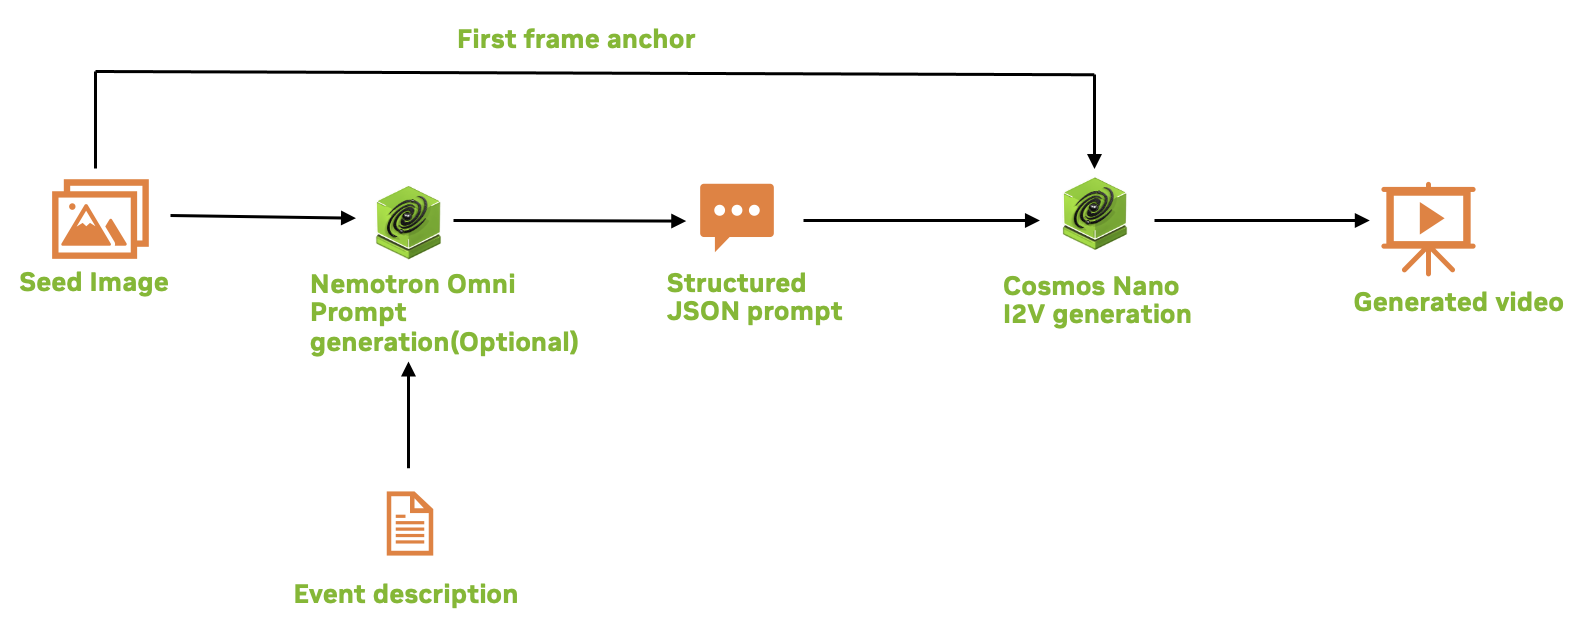

### 2.1 Environment Setup

The Cosmos Framework is **pre-installed** in this lab at `/opt/cosmos3-framework` (in its own virtual environment — separate from this kernel — which the inference cells launch as a subprocess on GPU 1), so there is no clone or `uv sync` step. The cell below verifies that the Cosmos framework, model caches, and your augmented image from Part 1 are all in place before running inference.

**Model checkpoints:** Cosmos3-Nano and the safety guardrail model are pre-staged locally in the Hugging Face cache — nothing is downloaded, and no token is needed.

This notebook uses **Cosmos3-Nano** by default — a 16B parameters single-GPU model optimized for fast iteration. **Cosmos3-Super** (32B parameters, requires 2 GPUs) produces significantly higher visual quality and better motion realism, and is the recommended choice for final dataset generation. To switch (outside this lab, where only Nano is pre-staged), set `COSMOS3_CHECKPOINT_PATH=Cosmos3-Super`, `COSMOS_GPU=0,1`, and `COSMOS3_NUM_GPUS=2` before running the inference cells.

Each inference run in Parts 2 and 3 saves its outputs to a timestamped subfolder so nothing is overwritten:
- `assets/outputs/i2v/YYYYMMDD_HHMMSS/` — generated video, payload, and metadata
- `assets/outputs/transfer_edge/YYYYMMDD_HHMMSS/` — transferred video, spec, and metadata


In [ ]:
# 2.1 Cosmos environment check (paths, GPU index and offline settings come from the environment block at the top)
import os
from pathlib import Path

# Input image for I2V: the edit generated in this kernel by 1.3 - the seed -> I2I -> I2V chain is the point of the lab
if globals().get("augmented_image_path") is None or not Path(augmented_image_path).exists():
    print("NOTE: No Qwen edit from this session — falling back to the seed image as I2V input.")
    print("      Run sections 1.1–1.3 to generate an augmented version and use that instead.")
    AUGMENTED_IMAGE = seed_image_path
else:
    AUGMENTED_IMAGE = Path(augmented_image_path)
print(f"I2V input: {AUGMENTED_IMAGE}")

# Offline sanity checks - every path below must already exist; nothing is downloaded in this lab
_hub = HF_HOME / "hub"
_ref_main = _hub / "models--nvidia--Cosmos3-Nano" / "refs" / "main"
_checks = {
    "Cosmos framework repo": COSMOS3_REPO,
    "Cosmos framework venv python": COSMOS3_VENV_PYTHON,
    "Cosmos3-Nano snapshot": _hub / "models--nvidia--Cosmos3-Nano" / "snapshots" / COSMOS3_NANO_REVISION,
    "Cosmos3-Nano refs/main": _ref_main,
    "Cosmos-Guardrail1 snapshot": _hub / "models--nvidia--Cosmos-Guardrail1" / "snapshots" / COSMOS_GUARDRAIL_REVISION,
    "Qwen3Guard text guardrail refs/main": _hub / "models--Qwen--Qwen3Guard-Gen-0.6B" / "refs" / "main",
    "Wan2.2 video VAE": _hub / "models--Wan-AI--Wan2.2-TI2V-5B" / "snapshots" / WAN_VAE_REVISION / "Wan2.2_VAE.pth",
}
_all_ok = True
for _k, _p in _checks.items():
    _ok = _p.exists()
    _all_ok &= _ok
    print(f"{'OK     ' if _ok else 'MISSING'} {_k}: {_p}")
if _ref_main.exists() and _ref_main.read_text().strip() != COSMOS3_NANO_REVISION:
    print(f"WARNING refs/main points at {_ref_main.read_text().strip()[:12]}..., expected {COSMOS3_NANO_REVISION[:12]}... (the framework requests revision 'main')")
print(f"\nCheckpoint: {COSMOS3_CHECKPOINT} | Cosmos GPU: {COSMOS_GPU} (subprocess only) | GPUs per run: {os.environ['COSMOS3_NUM_GPUS']}")
print(f"Master: {os.environ['COSMOS3_MASTER_ADDR']}:{os.environ['COSMOS3_MASTER_PORT']} | HF_HOME: {HF_HOME} (offline)")
if not _all_ok:
    print("\nA cache or the framework is MISSING. The lab data loader may still be running - wait a few minutes and re-run. Do not set HF_TOKEN or download anything.")

Confirm the GPU is visible to the Cosmos environment before proceeding. If `cuda available: False`, the inference cells will fail — check your GPU allocation.

In [ ]:
import os, subprocess
from pathlib import Path
if not Path(str(COSMOS3_VENV_PYTHON)).exists():
    raise FileNotFoundError(f"Cosmos environment python not found at {COSMOS3_VENV_PYTHON} (MISSING in the 2.1 check above). Wait for the course loader / ask an instructor before continuing.")

_env = {**os.environ, "CUDA_VISIBLE_DEVICES": COSMOS_GPU, "LD_LIBRARY_PATH": ""}
_code = (
    "import torch; "
    "print(f'Cosmos env: torch {torch.__version__} | cuda {torch.version.cuda} | cuda available: {torch.cuda.is_available()} | visible devices: {torch.cuda.device_count()}'); "
    "[print(f'  visible device {i}: {torch.cuda.get_device_name(i)} | {torch.cuda.mem_get_info(i)[0] / 1024**3:.0f} GiB free') for i in range(torch.cuda.device_count())]"
)
_res = subprocess.run([str(COSMOS3_VENV_PYTHON), "-c", _code], env=_env, cwd=str(COSMOS3_REPO), capture_output=True, text=True)
print(_res.stdout.strip() or _res.stderr.strip())
if _res.returncode != 0 or "visible devices: 1" not in _res.stdout:
    print(f"\nWARNING: the Cosmos environment cannot see exactly one GPU (physical GPU {COSMOS_GPU}). Ask an instructor before running inference.")

### 2.2 Structured Prompts

Cosmos uses **structured JSON prompts** rather than a single string. The structure separates scene description into semantic components, giving the model stronger grounding on what to generate.

The key fields:

| Field | What it controls |
|---|---|
| `subjects[].description` | What the main element(s) are |
| `subjects[].action` | **The motion** — what happens during the clip |
| `subjects[].appearance_details` | Surface, color, texture details to preserve |
| `subjects[].orientation` / `pose` / `number_of_subjects` | Additional per-subject grounding |
| `background_setting` | Environment, geometry, first-frame anchor instruction |
| `lighting` | Illumination conditions, shadows, atmosphere |
| `aesthetics` | Composition, color scheme, mood, patterns |
| `cinematography` | Camera motion, framing, angle, and first-frame preservation |

**For I2V specifically:**
- The `action` field is the most important — it is the primary driver of what the model generates
- Include `"Use the provided image as the exact first frame"` in `background_setting` and `cinematography.camera_preservation` to signal the anchor
- Describe *motion*, not static appearance — the image already provides appearance context
- `cinematography.camera_motion` should state the camera is fixed/locked unless a motion-control checkpoint is being used

The full schema — including the `aesthetics`, `cinematography`, and `negative_prompt` fields — is defined in [`assets/prompts/i2v_prompt_schema.json`](assets/prompts/i2v_prompt_schema.json). Two traffic-specific scenario prompts are provided in `assets/prompts/` as a starting point — select one in the preset menu below, or use section 2.2.1 to generate your own with AI.


### 2.2.1 Generate a Prompt with AI (Optional)

Writing a well-structured Cosmos prompt by hand requires you to think through dozens of fields — subjects, actions, lighting, cinematography, control guidance, negative prompts — and get their interactions right. That's a lot of configuration for what is often a simple intent like "vehicles moving through a snowy intersection."

This section uses an LLM to bridge that gap. You describe what you want in plain natural language, and the model translates it into a correctly structured JSON prompt tailored to the Cosmos generation format. This saves time, removes the need to understand every field, and tends to produce more internally consistent prompts than writing them by hand.

We use **`nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`** (Nemotron 3 Nano Omni) running as a **local NIM** on GPU 0 (port 30083) to generate a structured JSON prompt from your augmented image and description. Once generated, the prompt is automatically picked up by the preset menu below — no extra configuration needed.

**Why Nemotron Omni?** Nemotron 3 Nano Omni is a multimodal reasoning model — it can see your augmented image *and* read your text description at the same time, so the prompt it generates is grounded in the actual visual content of your scene, not just the text alone. This makes it well-suited for tasks like prompt generation where the output needs to match a specific input image and adhere to a structured schema.

If you prefer to skip this step, pre-written scenario prompts are available further below.

The container image is pre-pulled and the model cache is pre-seeded by the course loader, exactly like the Lab 1 NIM: nothing is downloaded and no API key is needed. Startup takes ~2-3 minutes.

In [ ]:
import subprocess, time, os, urllib.request, urllib.error
from pathlib import Path

_docker_env = os.environ.copy()

if subprocess.run(["docker", "-H", DOCKER_HOST, "image", "inspect", NEMOTRON_NIM_IMAGE],
                  env=_docker_env, capture_output=True).returncode != 0:
    raise RuntimeError(f"Image {NEMOTRON_NIM_IMAGE} is not in the inner daemon yet. The course seeds it at launch (vss-deploy, COURSE_EXTRA_IMAGES); "
                       "that takes several minutes on a fresh VM - wait and re-run this cell. If it never appears, ask a TA.")
if not (NEMOTRON_NIM_CACHE / NEMOTRON_NIM_CACHE_MARKER).exists():
    _cache_bytes = sum(p.stat().st_size for p in NEMOTRON_NIM_CACHE.rglob("*") if p.is_file() and not p.is_symlink()) if NEMOTRON_NIM_CACHE.is_dir() else 0
    raise RuntimeError(f"NIM cache {NEMOTRON_NIM_CACHE} is still staging ({_cache_bytes / 1e9:.1f} GB so far; marker {NEMOTRON_NIM_CACHE_MARKER} not present). "
                       "The course loader copies it at launch and this cache lands last - wait a few minutes and re-run this cell, or ask a TA.")

# Stop any leftover container (frees the name and the published port)
subprocess.run(["docker", "-H", DOCKER_HOST, "rm", "-f", NEMOTRON_NIM_CONTAINER],
               env=_docker_env, capture_output=True)

_nim_log = open(OUTPUTS / "nemotron_nim.log", "w")
_nim_proc = subprocess.Popen(
    ["docker", "-H", DOCKER_HOST, "run", "--rm", "--name", NEMOTRON_NIM_CONTAINER,
     "-u", "0",                                          # the pre-seeded cache is root-owned; the NIM's default uid 1000 cannot write there
     "--gpus", f"device={QWEN_GPU}",
     "--shm-size=32GB",                                  # no --ipc host: it would share dind's /dev/shm and silently discard this size (the NIM docs use --shm-size alone)
     "-e", "NGC_API_KEY=not-needed-cache-preseeded",     # placeholder only: with a complete cache the NIM never contacts NGC
     "-e", "NIM_MAX_MODEL_LEN=32768",
     "-v", f"{NEMOTRON_NIM_CACHE}:/opt/nim/.cache",
     "-p", f"{NEMOTRON_NIM_PORT}:8000",
     NEMOTRON_NIM_IMAGE],
    env=_docker_env,
    stdout=_nim_log, stderr=subprocess.STDOUT,
)
print(f"Nemotron NIM starting (container {NEMOTRON_NIM_CONTAINER}, GPU {QWEN_GPU}, log: {_nim_log.name}) ...")
print("Weights load from the pre-seeded cache: ready in ~2-3 min.")

for _attempt in range(180):  # 15 min
    if _nim_proc.poll() is not None:
        raise RuntimeError(f"Nemotron NIM exited with code {_nim_proc.returncode} - read {_nim_log.name} or ask a TA.")
    try:
        if urllib.request.urlopen(f"{NEMOTRON_NIM_BASE_URL}/v1/health/ready", timeout=3).status == 200:
            print(f"\nNemotron NIM ready after {_attempt * 5}s")
            break
    except (urllib.error.URLError, OSError):
        pass
    if _attempt % 6 == 0:
        print(f"  still waiting ({_attempt * 5}s elapsed)...", flush=True)
    time.sleep(5)
else:
    subprocess.run(["docker", "-H", DOCKER_HOST, "rm", "-f", NEMOTRON_NIM_CONTAINER],   # force-remove the half-loaded NIM so GPU 0 is freed
                   env=_docker_env, capture_output=True)
    _nim_proc.wait(timeout=30)                          # the attached docker run exits once the container is gone
    raise TimeoutError(f"Nemotron NIM did not become ready in 15 min. Read {_nim_log.name} or ask a TA.")


**Section 2.2.1 has four cells that must run in order:**

1. **Launch** (above) — starts the NIM and waits for it to report ready. Do not run the cells below until you see *"Nemotron NIM ready."*
2. **Describe your video** (next cell) — set `VIDEO_DESCRIPTION` to tell the NIM what motion you want to generate.
3. **Call the NIM** — sends your image and description to Nemotron; stores the raw response.
4. **Parse and save** — extracts the JSON prompt and saves it so the preset menu picks it up automatically.

In [ ]:
# --- 2.2.1 Describe the video you want to generate ---
# Tell the NIM what motion should happen in your clip.
# Be specific about what moves, how, and where.
VIDEO_DESCRIPTION = "Multiple vehicles driving through a snowy morning intersection with light snow on the road surfaces."
# -------------------------------------------------------
print(f"Video description: {VIDEO_DESCRIPTION}")

In [ ]:
# 2.2.1 — Call Nemotron NIM for I2V prompt generation.
import base64, json, re
from openai import OpenAI
from pathlib import Path
from IPython.display import JSON, display

_nemotron_client = OpenAI(base_url=f"{NEMOTRON_NIM_BASE_URL}/v1", api_key="EMPTY")

COSMOS_PROMPT_SCHEMA = (PROMPTS / "i2v_prompt_schema.json").read_text()
_system = f"""You are an expert at writing structured prompts for the Cosmos3 world foundation model for image-to-video (I2V) generation.

Given a seed image and a description of the desired action, produce a structured JSON prompt following this format:

{COSMOS_PROMPT_SCHEMA}

Critical rules:
- Output ONLY valid JSON - no markdown fences, no preamble, no explanation after
- The "action" field is the most important: describe physically realistic, specific motion
- Include the first-frame anchor in "background_setting" and "cinematography.camera_preservation" exactly as shown in the schema
- Describe motion, not static appearance
- "cinematography.camera_motion" should state the camera is fixed/locked unless told otherwise"""

_img_path = Path(str(globals().get("AUGMENTED_IMAGE", seed_image_path)))
_ext = _img_path.suffix.lower().lstrip(".")
_mime = "image/jpeg" if _ext in ("jpg", "jpeg") else f"image/{_ext}"
_img_b64 = base64.b64encode(_img_path.read_bytes()).decode()
_video_desc = globals().get("VIDEO_DESCRIPTION", "Multiple vehicles driving through a snowy morning intersection with light snow on the road surfaces.")

print(f"Sending {_img_path.name} + description to the Nemotron NIM...")
_completion = _nemotron_client.chat.completions.create(
    model=NEMOTRON_MODEL_ID,
    messages=[
        {"role": "system", "content": _system},
        {"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:{_mime};base64,{_img_b64}"}},
            {"type": "text", "text": f"Desired action: {_video_desc}\n\nGenerate the Cosmos3 structured JSON prompt."},
        ]},
    ],
    temperature=0.2, top_p=0.95, max_tokens=4096,                       # thinking off: the model card's instruct-mode temperature
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},   # reasoning off: JSON only, no chain-of-thought eating the token budget
)
nemotron_i2v_response = _completion.choices[0].message.content or ""
print("done")

In [ ]:
# 2.2.1 — Parse Nemotron I2V response and save.
import json, re
from pathlib import Path
from IPython.display import JSON, display

_raw = nemotron_i2v_response.strip()
_raw = re.sub(r"^```(?:json)?\s*\n?", "", _raw)
_raw = re.sub(r"\n?```\s*$", "", _raw)
_raw = _raw.strip()

_out_dir = Path(str(globals().get("GENERATED_PROMPTS_DIR", OUTPUTS / "prompts")))
_out_dir.mkdir(parents=True, exist_ok=True)

try:
    LLM_I2V_PROMPT_FILE_NEMOTRON = _out_dir / "llm_generated_prompt_nemotron.json"
    _parsed = json.loads(_raw)
    LLM_I2V_PROMPT_FILE_NEMOTRON.write_text(json.dumps(_parsed, indent=2))
    print(f"Saved: {LLM_I2V_PROMPT_FILE_NEMOTRON}")
    print("\nPrompt saved — it will be used automatically in the preset menu below.")
    display(JSON(_parsed, expanded=True))
except json.JSONDecodeError as e:
    print(f"Could not parse response as JSON: {e}")
    _raw_path = _out_dir / "llm_generated_prompt_nemotron_raw.txt"
    _raw_path.write_text(nemotron_i2v_response)
    print(f"Raw output saved to: {_raw_path}")
    print("\nRaw response:\n", nemotron_i2v_response)

If you skipped section 2.2.1, two pre-written scenario prompts are available in `assets/prompts/`. Set `I2V_SCENARIO` to choose one, pick a seed, and inspect the prompt below before running inference.


In [ ]:
# --- 2.2 Choose your I2V prompt ---
USE_LLM_PROMPT = True       # True  → use the NIM-generated prompt from section 2.2.1
                            # False → use a preset: set I2V_SCENARIO below
I2V_SCENARIO = "normal_traffic"   # "normal_traffic" | "stalled_vehicle"
I2V_SEED = 0                # same prompt + same seed → same clip; vary for diversity

In [ ]:
# 2.2 Load and display the selected I2V prompt.
import json
from pathlib import Path
from IPython.display import JSON, display

I2V_PROMPT_FILES = {
    "normal_traffic":    PROMPTS / "i2v_normal_traffic.json",
    "stalled_vehicle":   PROMPTS / "i2v_stalled_vehicle.json",
}
_llm_prompt = OUTPUTS / "prompts" / "llm_generated_prompt_nemotron.json"
if USE_LLM_PROMPT:
    if not _llm_prompt.exists():
        print("WARNING: No NIM-generated prompt found — run section 2.2.1 first, or set USE_LLM_PROMPT = False to use a preset.")
    CUSTOM_PROMPT_FILE = _llm_prompt if _llm_prompt.exists() else None
else:
    CUSTOM_PROMPT_FILE = None

if CUSTOM_PROMPT_FILE:
    I2V_NAME, SAMPLE_PROMPT_FILE = "custom", Path(CUSTOM_PROMPT_FILE)
else:
    assert I2V_SCENARIO in I2V_PROMPT_FILES, f"Unknown scenario {I2V_SCENARIO!r}; choose one of {list(I2V_PROMPT_FILES)}"
    I2V_NAME, SAMPLE_PROMPT_FILE = I2V_SCENARIO, I2V_PROMPT_FILES[I2V_SCENARIO]
if not SAMPLE_PROMPT_FILE.exists():
    raise FileNotFoundError(f"Prompt file not found: {SAMPLE_PROMPT_FILE}")

prompt_data = json.loads(SAMPLE_PROMPT_FILE.read_text())
print(f"Scenario: {I2V_NAME} | seed: {I2V_SEED} | file: {SAMPLE_PROMPT_FILE.name}")
display(JSON(prompt_data, expanded=True))

### 2.3 Run Image-to-Video Inference

**Image-to-video best practices:**

- **Keep `action` grounded in the image**: if your image shows a vehicle on a road, the action should describe vehicle motion — not flying or teleporting
- **Camera stays fixed**: Cosmos I2V uses a locked camera by default; don't describe camera motion unless using a motion-control checkpoint
- **`seed`**: fix it to reproduce results; vary it across runs to get motion diversity from the same prompt

**Key generation parameters:**

| Parameter | What it does | Typical range |
|---|---|---|
| `num_steps` | Number of denoising steps — more steps = higher quality, slower generation | 20–50 |
| `guidance` | How strictly the model follows the prompt vs. exploring freely — higher = closer to prompt | 4.0–7.0 |
| `shift` | Controls the noise schedule; affects motion sharpness and temporal consistency | 2.0–10.0 |
| `fps` | Frames per second of the output video | 24–30 |
| `num_frames` | Total frames generated — at 24 fps: 121 frames ≈ 5 s, 193 frames ≈ 8 s | 121–193 |
| `resolution` | Output resolution — `"480"` is faster to generate, `"720"` gives higher visual quality | `"480"` / `"720"` |

Run the cell below to assemble the payload from your prompt file and input image, and preview what will be sent to the inference script.


In [ ]:
# 2.3 Assemble the I2V payload. Requires 2.1 (AUGMENTED_IMAGE) and the preset menu (SAMPLE_PROMPT_FILE, I2V_SEED).
import json, os
from pathlib import Path
from datetime import datetime
from IPython.display import Image as IPImage, display

for _name in ("AUGMENTED_IMAGE", "SAMPLE_PROMPT_FILE", "I2V_SEED"):
    if _name not in globals():
        raise RuntimeError("Run the 2.1 environment check and the 2.2 preset menu first.")


def compact_json(path):
    return json.dumps(json.loads(Path(path).read_text()), ensure_ascii=True, separators=(",", ":"))


_neg_candidates = [
    ASSETS / "negative_prompt_i2v.json",
    COSMOS_ROOT / "cookbooks" / "cosmos3" / "generator" / "audiovisual" / "assets" / "negative_prompts" / "image2video" / "neg_prompt.json",
    ASSETS / "negative_prompt.json",
]
neg_prompt_path = next((p for p in _neg_candidates if p.exists()), None)
if neg_prompt_path is None:
    raise FileNotFoundError(f"No I2V negative prompt found. Looked in: {[str(p) for p in _neg_candidates]}")
neg_prompt = compact_json(neg_prompt_path)

# --- Inference configuration (1x H100: 193 frames / 50 steps / 480p ≈ 3-4 min) ---
I2V_SAMPLING = {
    "num_steps": 50,
    "guidance": 6.0,        # valid range 0-7
    "shift": 3.0,
    "fps": 24,
    "num_frames": 193,      # 121 = ~5s (faster)  |  193 = ~8s
    "resolution": "480",    # "480" fits the time budget  |  "720" higher quality, slower
    "aspect_ratio": "16,9",
    "seed": I2V_SEED,       # from the preset
}
# --------------------------------

# Each run gets its own timestamped folder
RUN_I2V = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{I2V_NAME}_s{I2V_SEED}"
I2V_RUN_DIR = OUTPUTS / "i2v" / RUN_I2V
I2V_RUN_DIR.mkdir(parents=True, exist_ok=True)

payload_path = I2V_RUN_DIR / "payload.json"
payload = {
    "model_mode": "image2video",
    "name": "sdg_i2v",
    "prompt": compact_json(SAMPLE_PROMPT_FILE),
    "negative_prompt": neg_prompt,
    "enable_sound": False,
    **I2V_SAMPLING,
    "vision_path": str(Path(AUGMENTED_IMAGE).resolve()),
}

payload_path.write_text(json.dumps(payload, indent=2) + "\n")
os.environ["SDG_I2V_PAYLOAD"] = str(payload_path)
os.environ["SDG_I2V_OUTPUT"] = str(I2V_RUN_DIR)
os.environ["SDG_I2V_RUN"] = RUN_I2V
os.environ["SDG_I2V_SEED"] = str(I2V_SAMPLING["seed"])

print(f"Run:      {RUN_I2V}")
print(f"Payload:  {payload_path}")
print(f"Output:   {I2V_RUN_DIR}")
print(f"Neg. prompt: {neg_prompt_path}")
print(json.dumps({k: payload[k] for k in ["model_mode", "num_steps", "guidance", "fps", "num_frames", "resolution", "seed"]}, indent=2))
print("Input image:")
display(IPImage(filename=str(AUGMENTED_IMAGE), width=480))


I2V generation starts here — this calls the Cosmos inference script and will take 2–4 minutes. Progress logs stream in the output as the model runs.


In [ ]:
%%bash
set -euo pipefail
cd "$COSMOS3_REPO"
export CUDA_VISIBLE_DEVICES="$COSMOS_CUDA_VISIBLE_DEVICES"
export LD_LIBRARY_PATH=
.venv/bin/torchrun \
  --nproc-per-node="$COSMOS3_NUM_GPUS" \
  --master-addr="$COSMOS3_MASTER_ADDR" \
  --master-port="$COSMOS3_MASTER_PORT" \
  -m cosmos_framework.scripts.inference \
  --parallelism-preset=throughput \
  -i "$SDG_I2V_PAYLOAD" \
  -o "$SDG_I2V_OUTPUT" \
  --checkpoint-path "$COSMOS3_CHECKPOINT_PATH" \
  --seed="$SDG_I2V_SEED"


Once generation finishes, run the cell below to find and play the output video inline.

**After running, here is what to look for:**
- Does the first frame match your input image?
- Does the motion match the action described in your prompt?
- Is the motion physically coherent — no teleporting subjects, flickering, or abrupt scene cuts?
- Would you keep this clip, try a different seed, adjust the parameters, or adjust the prompt?

In [ ]:
import base64, json, os
import html as html_lib
from pathlib import Path
from IPython.display import HTML, display


def display_video(path, width=720):
    data = base64.b64encode(Path(path).read_bytes()).decode("ascii")
    label = html_lib.escape(str(path))
    display(HTML(
        f'<video controls playsinline width="{width}" style="max-width:100%; background:#000">'
        f'<source src="data:video/mp4;base64,{data}" type="video/mp4"></video>'
        f'<div style="font-family:monospace;font-size:12px;margin-top:4px">{label}</div>'
    ))


_run_dir = globals().get("I2V_RUN_DIR")
if _run_dir is None:
    raise RuntimeError("Run the 2.3 payload cell and the inference cell first.")
generated_video = None
_expected = Path(_run_dir) / "sdg_i2v" / "vision.mp4"
if _expected.exists():
    generated_video = _expected
else:
    _cands = [p for p in Path(_run_dir).rglob("*.mp4") if not p.name.endswith(("_preview.mp4", "_browser.mp4"))]
    generated_video = max(_cands, key=lambda p: p.stat().st_mtime) if _cands else None
if generated_video is None:
    raise FileNotFoundError(f"No I2V clip under {_run_dir} - the inference cell above did not complete; read its output and re-run it.")

print(f"Video:  {generated_video} ({generated_video.stat().st_size // 1024} KB)")
display_video(generated_video)
os.environ["SDG_GENERATED_VIDEO"] = str(generated_video)

meta = {
    "stage": "i2v", "run": RUN_I2V, "model": COSMOS3_CHECKPOINT, "model_revision": COSMOS3_NANO_REVISION,
    "scenario": I2V_NAME, "source_image": str(AUGMENTED_IMAGE), "prompt_file": str(SAMPLE_PROMPT_FILE),
    "negative_prompt_file": str(neg_prompt_path), "sampling": I2V_SAMPLING,
    "effective_seed": int(os.environ["SDG_I2V_SEED"]), "output": str(generated_video),
}
(Path(I2V_RUN_DIR) / "meta.json").write_text(json.dumps(meta, indent=2))
print(f"Provenance saved: {Path(I2V_RUN_DIR) / 'meta.json'}")

If the clip doesn't match your intent, go back to the payload cell above, adjust the parameters in `I2V_SAMPLING`, and rerun the payload and inference cells. Each run is saved to a timestamped folder under `assets/outputs/i2v/` so all previous results are preserved.


You can repeat the payload and inference cells with a different `seed` or a different prompt file to generate additional motion variants of the same image. Each variant expands your training dataset along the temporal axis.


---
## Part 3: Video Augmentation with Cosmos

*Estimated time: ~10 minutes (GPU 1).*

So far, we've used Cosmos 3 to generate videos from scratch, based on a prompt and initial image. Generating each video takes several minutes of GPU compute. V2V transfer lets you multiply the value of that compute: instead of re-running the full generation pipeline for every appearance variant you need, you take an existing generated video and re-render its visual appearance — materials, lighting, surface textures, environment style — while reusing the motion and structure already generated. One video clip under snowy conditions becomes the same clip under rainy night, dense fog, or dry nighttime conditions, each as a separate training sample. This compounds directly with the earlier stages: N images × M motion clips × K transfer variants gives you N×M×K training samples from a single seed image.

Cosmos3 Transfer achieves this by extracting a structural control signal from the source video and conditioning generation on that signal rather than on the raw pixels. The prompt drives the new appearance, while the control signal enforces structural fidelity. Note that fine details and fast motion can still shift — outputs should be reviewed for structural fidelity.

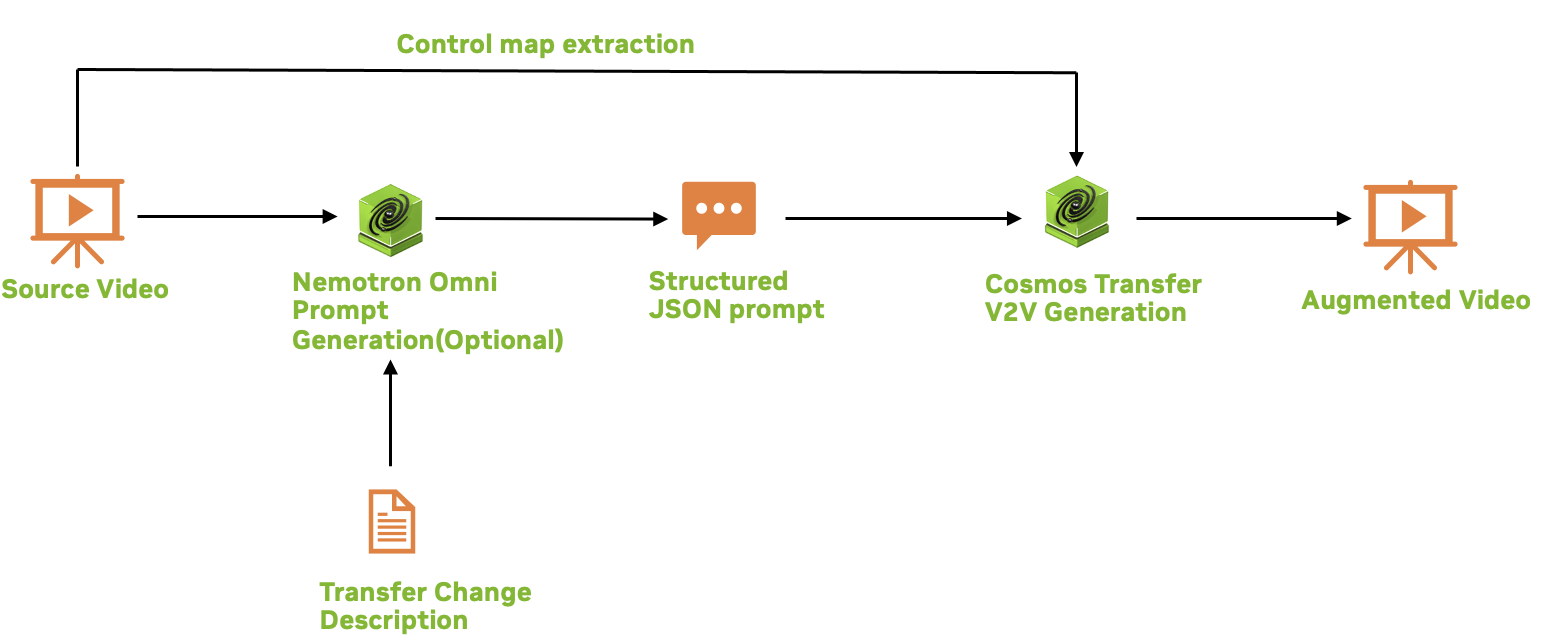

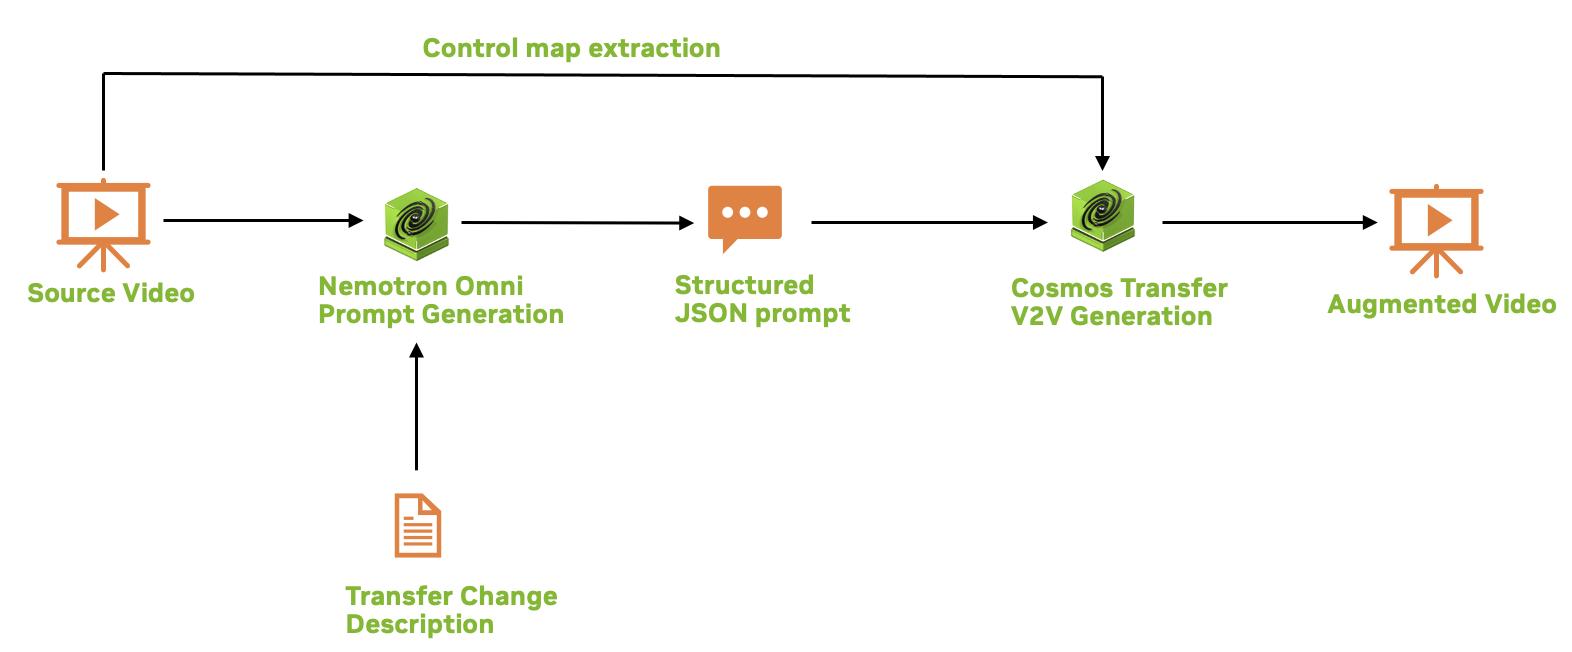

### 3.1 Transfer Controls

Five control modalities are available. Each extracts a different type of structural information from the source video:

| Control | Signal extracted | What it preserves | Best for |
|---|---|---|---|
| **Edge** | Canny edge map | Shapes, layout, fine structural detail | Material / texture changes, environment style |
| **Blur** | Low-frequency appearance | Colors, overall spatial layout | Subtle look changes, stylization |
| **Depth** | Monocular depth map | 3D structure, spatial scale, Z-ordering | Relighting, surface material changes |
| **Segmentation** | Semantic segment map | Object identity and region boundaries | Replacing backgrounds, object appearance swap |
| **WSM** | World-scenario map | High-level scene semantics | Broad scene-type transfer |

Edge is the most broadly applicable starting point — it preserves fine structural detail and allows significant appearance change. This notebook runs an edge transfer; the spec format is identical for all control types, changing only the control key.

**Transfer prompt best practices:**
- Describe the *target appearance*, not the source — the structure comes from the control signal, not the prompt
- Be specific about new conditions: `"nighttime, wet surfaces, sodium vapor streetlights"` works better than `"dark scene"`
- `guidance` (valid range 0–7) controls how strongly the generated video follows your **text prompt** — the appearance, materials, weather, and lighting you described
- `control_guidance` (valid range 0–10) controls how strongly the generated video follows the **control video** — how rigidly it enforces the Edge map's structure (vehicle silhouettes, lane boundaries, scene geometry). At `1.0` it's a no-op; pushing it higher enforces the source structure more strictly, at the cost of the model's freedom to deviate for the sake of the new appearance

These two are independent CFG knobs applied in separate forward passes — `guidance` pulls toward your prompt's appearance, `control_guidance` pulls toward the control signal's structure. Raise `guidance` if the appearance isn't changing enough; raise `control_guidance` if vehicles/edges are drifting or losing structural fidelity.


### 3.1.1 Generate a Transfer Prompt with AI (Optional)

Just as in section 2.2.1, writing a detailed transfer prompt by hand means specifying lighting conditions, surface materials, precipitation, prohibited changes, and more across many fields. Here you can describe your target appearance in plain language — "rainy night with wet reflective roads" — and let the model produce a correctly structured JSON prompt from that description and your source video.

Uses **`nvidia/nemotron-3-nano-omni-30b-a3b-reasoning`** (Nemotron 3 Nano Omni) running as a **local NIM** on port 30083 (launched in section 2.2.1) to generate a structured JSON transfer prompt from your source video and target-appearance description. Once generated, the prompt is automatically picked up by the transfer configuration below.

If you prefer to skip this step, pre-written transfer prompts are available further below.

In [ ]:
# --- 3.1.1 Describe the appearance you want to transfer to ---
# Tell the NIM what the scene should look like after transfer.
# Focus on weather, lighting, surface conditions, and time of day.
TRANSFER_DESCRIPTION = "Change the scene to a rainy night with active rainfall, wet reflective roads, rain streaks, puddle ripples, and streetlights glowing through rain."
# -------------------------------------------------------
print(f"Transfer description: {TRANSFER_DESCRIPTION}")

In [ ]:
# 3.1.1 — Call Nemotron NIM for transfer prompt generation.
# Set TRANSFER_DESCRIPTION in the cell above to control what appearance the NIM generates.
import base64, json, re, subprocess, urllib.request, urllib.error
from openai import OpenAI
from pathlib import Path
from IPython.display import JSON, display

try:
    urllib.request.urlopen(f"{NEMOTRON_NIM_BASE_URL}/v1/health/ready", timeout=3)
except urllib.error.HTTPError as _e:                   # HTTPError is a URLError subclass: catch it first
    raise RuntimeError(f"Nemotron NIM at {NEMOTRON_NIM_BASE_URL} answered HTTP {_e.code}: it is still loading weights. "
                       "Wait for the 2.2.1 launch cell to report ready, then re-run this cell.") from None
except (urllib.error.URLError, OSError):
    raise RuntimeError(f"Nemotron NIM is not reachable at {NEMOTRON_NIM_BASE_URL}. Run the 2.2.1 launch cell first, "
                       "or skip 3.1.1 and pick a shipped transfer prompt below (TRANSFER_SCENARIO).") from None

_nemotron_client = OpenAI(base_url=f"{NEMOTRON_NIM_BASE_URL}/v1", api_key="EMPTY")

TRANSFER_PROMPT_SCHEMA = (PROMPTS / "transfer_prompt_schema.json").read_text()
_system_transfer = f"""You are an expert at writing structured prompts for the Cosmos3 world foundation model for video-to-video (V2V) appearance transfer.

Given a source video and a description of the desired new appearance, produce a structured JSON prompt in exactly this format:

{TRANSFER_PROMPT_SCHEMA}

Critical rules:
- Output ONLY valid JSON - no markdown fences, no preamble, no explanation after
- Describe ONLY the target appearance change: materials, lighting, weather, time of day, surface conditions
- Every field describing motion or behavior must state it is identical to the source video
- "background_setting" must include: 'The same structural layout and scene geometry as the source video'
- "control_guidance.control_type" must be "Edge"
- "environmental_transformation.prohibited_changes" must list concrete things not to change"""

# Source video: use from 3.1.1 config cell if available, otherwise find latest I2V output
if "_transfer_source_video" not in globals():
    _saved = sorted((OUTPUTS / "i2v").rglob("vision.mp4"), key=lambda p: p.stat().st_mtime) if (OUTPUTS / "i2v").exists() else []
    if not _saved:
        raise RuntimeError("No generated video found under outputs/i2v. Run Part 2 first.")
    _transfer_source_video = _saved[-1]
    print(f"Using latest I2V output: {_transfer_source_video}")

_out_dir = Path(str(globals().get("GENERATED_PROMPTS_DIR", OUTPUTS / "prompts")))
_out_dir.mkdir(parents=True, exist_ok=True)

# Always compress before sending: keep the base64 video payload small for the NIM
_compressed = _out_dir / f"{_transfer_source_video.stem}_nemotron_compressed.mp4"
subprocess.run(
    ["ffmpeg", "-y", "-i", str(_transfer_source_video), "-vf", "scale=480:-2",
     "-c:v", "libx264", "-crf", "30", "-preset", "fast", "-an", str(_compressed)],
    check=True, capture_output=True,
)
_video_for_nemotron = _compressed
print(f"Compressed video: {_compressed.stat().st_size / 1024**2:.1f} MB (for prompt only; full video used in transfer)")

_video_b64 = base64.b64encode(_video_for_nemotron.read_bytes()).decode()
_transfer_desc = globals().get("TRANSFER_DESCRIPTION", "Change the scene to a rainy night with active rainfall, wet reflective roads, rain streaks, puddle ripples, and streetlights glowing through rain.")

print(f"Sending {_video_for_nemotron.name} + description to the Nemotron NIM...")
_completion = _nemotron_client.chat.completions.create(
    model=NEMOTRON_MODEL_ID,
    messages=[
        {"role": "system", "content": _system_transfer},
        {"role": "user", "content": [
            {"type": "video_url", "video_url": {"url": f"data:video/mp4;base64,{_video_b64}"}},
            {"type": "text", "text": f"Desired new appearance: {_transfer_desc}\n\nGenerate the Cosmos3 structured JSON transfer prompt."},
        ]},
    ],
    temperature=0.2, top_p=0.95, max_tokens=4096,                       # thinking off: the model card's instruct-mode temperature
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},   # reasoning off: JSON only, no chain-of-thought eating the token budget
)
nemotron_transfer_response = _completion.choices[0].message.content or ""
print("done")

In [ ]:
# 3.1.1 — Parse Nemotron transfer response and save.
import json, re
from pathlib import Path
from IPython.display import JSON, display

_raw = nemotron_transfer_response.strip()
_raw = re.sub(r"^```(?:json)?\s*\n?", "", _raw)
_raw = re.sub(r"\n?```\s*$", "", _raw)
_raw = _raw.strip()

_out_dir = Path(str(globals().get("GENERATED_PROMPTS_DIR", OUTPUTS / "prompts")))
_out_dir.mkdir(parents=True, exist_ok=True)

try:
    LLM_TRANSFER_PROMPT_FILE_NEMOTRON = _out_dir / "llm_generated_transfer_prompt_nemotron.json"
    _parsed = json.loads(_raw)
    LLM_TRANSFER_PROMPT_FILE_NEMOTRON.write_text(json.dumps(_parsed, indent=2))
    print(f"Saved: {LLM_TRANSFER_PROMPT_FILE_NEMOTRON}")
    print("\nPrompt saved — it will be used automatically in the transfer configuration below.")
    display(JSON(_parsed, expanded=True))
except json.JSONDecodeError as e:
    print(f"Could not parse response as JSON: {e}")
    _raw_path = _out_dir / "llm_generated_transfer_prompt_nemotron_raw.txt"
    _raw_path.write_text(nemotron_transfer_response)
    print(f"Raw output saved to: {_raw_path}")
    print("\nRaw response:\n", nemotron_transfer_response)

If you skipped section 3.1.1, four pre-written transfer prompts are available in `assets/prompts/`:

| Key | File | Scenario |
|---|---|---|
| `nighttime` | `transfer_nighttime.json` | Clear nighttime, dry roads, streetlights |
| `nighttime_rainy` | `transfer_nighttime_rainy.json` | Nighttime with active rainfall |
| `nighttime_snowy` | `transfer_nighttime_snowy.json` | Nighttime with heavy snowfall |
| `fog` | `transfer_fog.json` | Dense daytime fog, ~30–50 m visibility |

Set `TRANSFER_SCENARIO` to one of the keys above before running inference.

### 3.2 Run Edge Transfer

The default transfer prompt is `transfer_nighttime_rainy.json`. Three additional variants are available — change `TRANSFER_SCENARIO` in the configuration cell below to switch between them. See the table above for the full list.

**Model:** Transfer also uses **Cosmos3-Nano** by default. Switching to Cosmos3-Super produces sharper edge adherence and more photorealistic appearance results, at the cost of requiring multiple GPUs and longer generation time.

This configures the transfer: locates the video generated in Part 2, selects the edge control modality, and writes the spec file the inference script will read.


In [ ]:
# --- Choose your transfer prompt ---
USE_LLM_PROMPT = True         # True  → use the NIM-generated prompt from section 3.1.1
                              # False → use a preset: set TRANSFER_SCENARIO below
TRANSFER_SCENARIO = "nighttime_rainy"   # "nighttime" | "nighttime_rainy" | "nighttime_snowy" | "fog"
TRANSFER_SEED = 0             # same prompt + same seed → same clip; vary for diversity

In [ ]:
# 3.2 Configure the edge transfer
import json, os
from datetime import datetime
from pathlib import Path


def compact_json(path):
    return json.dumps(json.loads(Path(path).read_text()), ensure_ascii=True, separators=(",", ":"))


if "find_source_video" not in globals():
    def find_source_video():
        # Source video: this session's I2V clip, or the latest saved I2V run in outputs/
        _env_video = os.environ.get("SDG_GENERATED_VIDEO", "")
        if _env_video and Path(_env_video).exists():
            return Path(_env_video), "this session"
        _saved = sorted((OUTPUTS / "i2v").rglob("vision.mp4"), key=lambda p: p.stat().st_mtime) if (OUTPUTS / "i2v").exists() else []
        if _saved:
            return _saved[-1], "latest saved I2V run"
        raise FileNotFoundError(f"No generated video found under {OUTPUTS / 'i2v'}. Run Part 2 first.")

source_video, _src = find_source_video()
print(f"Source video ({_src}): {source_video}")

# 3.2 Load and display the selected transfer prompt.
TRANSFER_PROMPT_FILES = {
    "nighttime":        PROMPTS / "transfer_nighttime.json",
    "nighttime_rainy":  PROMPTS / "transfer_nighttime_rainy.json",
    "nighttime_snowy":  PROMPTS / "transfer_nighttime_snowy.json",
    "fog":              PROMPTS / "transfer_fog.json",
}
_llm_transfer_prompt = OUTPUTS / "prompts" / "llm_generated_transfer_prompt_nemotron.json"
if USE_LLM_PROMPT:
    if not _llm_transfer_prompt.exists():
        print("WARNING: No NIM-generated transfer prompt found — run section 3.1.1 first, or set USE_LLM_PROMPT = False to use a preset.")
    CUSTOM_TRANSFER_PROMPT_FILE = _llm_transfer_prompt if _llm_transfer_prompt.exists() else None
else:
    CUSTOM_TRANSFER_PROMPT_FILE = None

if CUSTOM_TRANSFER_PROMPT_FILE:
    TRANSFER_NAME, transfer_prompt_path = "custom", Path(CUSTOM_TRANSFER_PROMPT_FILE)
else:
    assert TRANSFER_SCENARIO in TRANSFER_PROMPT_FILES, f"Unknown scenario {TRANSFER_SCENARIO!r}; choose one of {list(TRANSFER_PROMPT_FILES)}"
    TRANSFER_NAME, transfer_prompt_path = TRANSFER_SCENARIO, TRANSFER_PROMPT_FILES[TRANSFER_SCENARIO]
TRANSFER_NEG_PROMPT = ASSETS / "negative_prompt.json"
for _p in (transfer_prompt_path, TRANSFER_NEG_PROMPT):
    if not _p.exists():
        raise FileNotFoundError(f"Missing file: {_p}")

# Sampling settings: the whole 8 s clip in one pass, 45 steps, ~6 min on one H100.
_num_frames = 193
_num_steps = 45

RUN_V2V = datetime.now().strftime("%Y%m%d_%H%M%S") + f"_{TRANSFER_NAME}_s{TRANSFER_SEED}"
TRANSFER_RUN_DIR = OUTPUTS / "transfer_edge" / RUN_V2V
TRANSFER_RUN_DIR.mkdir(parents=True, exist_ok=True)
transfer_spec_path = TRANSFER_RUN_DIR / "spec.json"

# --- Transfer configuration ---
transfer_spec = {
    "name": "sdg_transfer_edge",
    "model_mode": "video2video",
    "vision_path": str(source_video.resolve()),
    "prompt": compact_json(transfer_prompt_path),
    "negative_prompt_file": str(TRANSFER_NEG_PROMPT),
    "edge": {"preset_edge_threshold": "medium"},
    "control_guidance": 1.5,     # valid range 0-10; 1.0 = off
    "guidance": 2.5,             # valid range 0-7
    "shift": 5.0,                # do not increase — higher values produce posterised, flickering texture at 480p
    "num_steps": _num_steps,
    "fps": 24,
    "num_frames": _num_frames,
    "resolution": "480",
    "aspect_ratio": "16,9",
    "seed": TRANSFER_SEED,
    "num_video_frames_per_chunk": _num_frames,   # single chunk = the whole clip
    "num_conditional_frames": 1,
    "num_first_chunk_conditional_frames": 0,
    "share_vision_temporal_positions": True,
    "negative_metadata_mode": "none",
    "negative_prompt_keep_metadata": False,
    "emphasize_control_in_prompt": False,
}

transfer_spec_path.write_text(json.dumps(transfer_spec, indent=2) + "\n")
os.environ["SDG_TRANSFER_SPEC"] = str(transfer_spec_path)
os.environ["SDG_TRANSFER_OUTPUT"] = str(TRANSFER_RUN_DIR)
os.environ["SDG_TRANSFER_SEED"] = str(transfer_spec["seed"])

print(f"Preset:        {TRANSFER_NAME} | seed {TRANSFER_SEED} | prompt {transfer_prompt_path.name}")
print(f"Run:           {RUN_V2V}")
print(f"Transfer spec: {transfer_spec_path}")
print(f"Output:        {TRANSFER_RUN_DIR}")
print(f"Settings:      {_num_frames} frames / {_num_steps} steps, single chunk (~6 min)")
print(json.dumps({k: transfer_spec[k] for k in ["model_mode", "num_steps", "guidance", "shift", "fps", "num_frames", "resolution", "control_guidance", "seed"]}, indent=2))

Next, Cosmos3 transfer does the augmentation. Expect about 10 minutes for the 8-second clip — progress logs will appear in the output.

In [ ]:
%%bash
set -euo pipefail
cd "$COSMOS3_REPO"
# LD_LIBRARY_PATH points at the venv's own CUDA 13 libraries (torchcodec needs the NPP libs there).
CUDA_VISIBLE_DEVICES="$COSMOS_CUDA_VISIBLE_DEVICES" LD_LIBRARY_PATH="$COSMOS3_REPO/.venv/lib/python3.13/site-packages/nvidia/cu13/lib" \
.venv/bin/python -m cosmos_framework.scripts.inference \
  --parallelism-preset=latency \
  --no-use-torch-compile \
  -i "$SDG_TRANSFER_SPEC" \
  -o "$SDG_TRANSFER_OUTPUT" \
  --checkpoint-path "$COSMOS3_CHECKPOINT_PATH" \
  --seed "$SDG_TRANSFER_SEED"


The cell below displays the original generated video and the transferred version side by side. Both clips have identical motion — only the lighting and surface appearance differ.

**After running, here is what to look for:**
- Did the appearance change to the conditions described in the transfer prompt?
- Does the transferred video retain the same motion and scene structure as the original?
- Are there areas where the control signal did not hold structure well?
- Would you keep this clip, increase `control_guidance` for tighter structure adherence, or try a different transfer control?


In [ ]:
# Side-by-side: source clip vs your edge transfer
import base64, json, os
import html as html_lib
from pathlib import Path
from IPython.display import HTML, display

if "transfer_spec" not in globals():
    raise RuntimeError("Run the 3.2 configuration cell first.")


def _pick_mp4(root):
    root = Path(root)
    if not root.exists():
        return None
    exact = root / "sdg_transfer_edge" / "vision.mp4"
    if exact.exists():
        return exact
    cands = [p for p in root.rglob("*.mp4") if not p.name.endswith(("_preview.mp4", "_browser.mp4", "control_edge.mp4"))]
    return max(cands, key=lambda p: p.stat().st_mtime) if cands else None


source_video_path = Path(transfer_spec["vision_path"])
transfer_video_path = _pick_mp4(TRANSFER_RUN_DIR)
if transfer_video_path is None:
    raise FileNotFoundError(f"No transfer output under {TRANSFER_RUN_DIR} - the transfer cell above did not complete; read its output and re-run it.")
label = f"Your edge transfer - {TRANSFER_NAME} (run {RUN_V2V})"

if not source_video_path.exists():
    print(f"Source video not found: {source_video_path} - re-run the 3.2 configuration cell.")
elif not transfer_video_path.exists():
    print(f"Transfer video not found: {transfer_video_path} - re-run the transfer cell.")
else:
    def _b64(p):
        return base64.b64encode(Path(p).read_bytes()).decode("ascii")

    display(HTML(f'''
<div style="display: flex; gap: 20px;">
  <div style="flex: 1;">
    <h3>Original Generated Video</h3>
    <video controls playsinline width="100%" style="background:#000">
      <source src="data:video/mp4;base64,{_b64(source_video_path)}" type="video/mp4">
    </video>
  </div>
  <div style="flex: 1;">
    <h3>{html_lib.escape(label)}</h3>
    <video controls playsinline width="100%" style="background:#000">
      <source src="data:video/mp4;base64,{_b64(transfer_video_path)}" type="video/mp4">
    </video>
  </div>
</div>
<p style="font-size: 12px; font-family: monospace;">
  Source: {html_lib.escape(str(source_video_path))} | Transfer: {html_lib.escape(str(transfer_video_path))}
</p>
'''))
    meta = {
        "stage": "v2v", "run": RUN_V2V, "model": COSMOS3_CHECKPOINT, "model_revision": COSMOS3_NANO_REVISION, "control": "edge",
        "preset": TRANSFER_NAME, "source_video": str(source_video_path), "prompt_file": str(transfer_prompt_path),
        "negative_prompt_file": str(TRANSFER_NEG_PROMPT), "spec": transfer_spec,
        "effective_seed": int(os.environ["SDG_TRANSFER_SEED"]), "output": str(transfer_video_path),
    }
    (TRANSFER_RUN_DIR / "meta.json").write_text(json.dumps(meta, indent=2))
    print(f"Provenance saved: {TRANSFER_RUN_DIR / 'meta.json'}")

If the transfer result doesn't match the target appearance, try adjusting `guidance` to follow the prompt more closely, swap `TRANSFER_SCENARIO` to a different prompt, or try a different control modality. Rerun the configuration and transfer cells — each run is saved to a timestamped folder under `assets/outputs/transfer_edge/` so all previous results are preserved.

---
## Part 4: Tear Down

*Estimated time: 2 minutes.*

The cell below stops Nemotron from GPU 0, stops any Cosmos inference process still running on GPU 1, and reports the free memory so both GPUs are free for the next part of the course. Do not skip this cell: a Nemotron NIM left running blocks the VSS deploy in the next part of the course.

In [ ]:
# Release both GPUs (safe to re-run)
import gc, subprocess, time
import torch

_pipe = globals().pop("qwen_pipeline", None)
if _pipe is not None:
    del _pipe
    globals().pop("result", None)
    print("Qwen Image Edit unloaded from this kernel.")
else:
    print("Qwen Image Edit was not loaded in this kernel.")
gc.collect()
torch.cuda.empty_cache()

# Stop any Cosmos inference subprocess still running (no-op if none)
_r = subprocess.run(["pkill", "-f", "cosmos_framework.scripts.inference"], capture_output=True, text=True)
print("Cosmos inference processes stopped." if _r.returncode == 0 else "No Cosmos inference process was running.")


# Stop the Nemotron NIM container launched in 2.2.1 (no-op if it is not running)
_r = subprocess.run(["docker", "-H", DOCKER_HOST, "rm", "-f", NEMOTRON_NIM_CONTAINER], capture_output=True, text=True)
if _r.returncode != 0:
    print(f"docker rm -f {NEMOTRON_NIM_CONTAINER} failed: {_r.stderr.strip()} - GPU {QWEN_GPU} may still be held; ask a TA.")
elif _r.stdout.strip():                                 # docker rm prints the name only when it really removed a container
    print("Nemotron NIM stopped.")
    for _ in range(12):
        time.sleep(5)
        _q = subprocess.run(["nvidia-smi", f"--id={QWEN_GPU}", "--query-gpu=memory.used,memory.total",
                             "--format=csv,noheader,nounits"], capture_output=True, text=True)
        if _q.returncode != 0 or not _q.stdout.strip():
            break
        _used, _total = (int(x) for x in _q.stdout.strip().split(","))
        if _used < 0.1 * _total:
            break
    else:
        print(f"WARNING: GPU {QWEN_GPU} still has {_used} MiB in use after 60 s - do not start the VSS part yet; ask a TA.")
else:
    print("No Nemotron NIM container was running.")

_q = subprocess.run(["nvidia-smi", "--query-gpu=index,memory.used,memory.total", "--format=csv,noheader,nounits"],
                    capture_output=True, text=True)
for _ln in _q.stdout.strip().splitlines():
    _idx, _used, _total = (int(x) for x in _ln.split(","))
    print(f"GPU {_idx}: {(_total - _used) / 1024:.0f} GiB free of {_total / 1024:.0f} GiB")
print("\nTo release the remaining CUDA context held by this kernel, choose Kernel > Shut Down Kernel when you are done reading the Review.")

---
## Review

You completed the generation-and-augmentation stage of an SDG pipeline, starting from a single seed image:

- **Qwen Image Edit (I2I)** changed the scene's appearance conditions → image variants with different environmental context
- **Cosmos3 I2V** generated motion from the augmented image → video clips with temporal dynamics
- **Cosmos3 Transfer (V2V)** re-rendered the video under new appearance conditions → appearance variants without re-shooting

The dataset scaling effect compounds across stages:

```
1 seed image
  × N edit prompts    → N augmented images
  × M motion prompts  → N × M generated videos
  × K transfer types  → N × M × K total training samples
```

Provenance for each stage is saved as `meta.json` in each run folder under `assets/outputs/` (`i2i/`, `i2v/`, `transfer_edge/`), recording the source, prompt, model, seed, and parameters used.

**Next steps to explore:**

- **Try other Cosmos3 models** — this notebook uses Cosmos3-Nano (fast, single GPU, good for iteration). Two other variants are available:
  - **Cosmos3-Super** (32B parameters, 2 GPUs) — significantly higher visual quality and motion realism; recommended for final dataset generation once your prompts are dialed in. Switch via `COSMOS3_CHECKPOINT_PATH=Cosmos3-Super` and `COSMOS3_NUM_GPUS=2`
  - **Cosmos3-Edge** (4B parameters, 1 GPU) - a lightweight model optimized for edge device deployment; useful when generating data to train models that will run on constrained hardware
- **More Qwen edits** — vary weather, time of day, sensor type, or object count to expand image-level diversity
- **More motion variants** — change `seed` in the I2V payload, swap to a different scenario prompt, edit a prompt manually to describe a different event, or use the AI section (2.2.1) to generate a new one from a plain-language description
- **Other transfer controls** — try `depth` for geometry-grounded relighting, `seg` for background replacement, or `blur` for style-level changes
- **Combine with annotation** — pair generated videos with bounding boxes, depth maps, or segmentation masks for fully labeled synthetic data
